In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
df = pd.read_csv("assets/indian_weather_data.csv")

In [8]:
features = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "pm2_5",
    "pm10",
    "cloudcover",
    "visibility"
]

X = df[features].dropna()

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

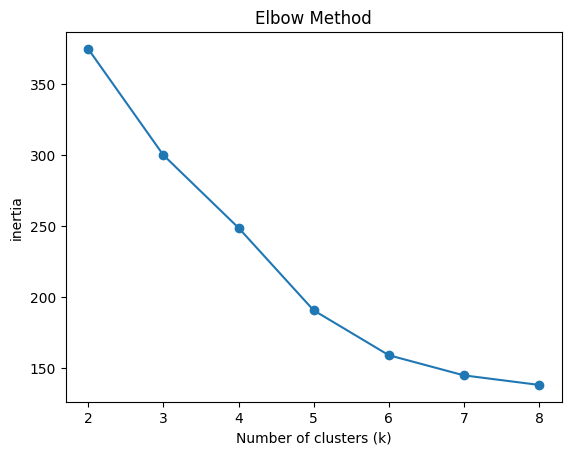

In [11]:
inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(2,9), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} -> Silhouette Score: {score:.3f}")

k=2 -> Silhouette Score: 0.371
k=3 -> Silhouette Score: 0.392
k=4 -> Silhouette Score: 0.347
k=5 -> Silhouette Score: 0.360
k=6 -> Silhouette Score: 0.334
k=7 -> Silhouette Score: 0.328
k=8 -> Silhouette Score: 0.342


In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)

In [15]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary

,temperature,humidity,wind_speed,pressure,pm2_5,pm10,cloudcover,visibility
cluster,,,,,,,,
0.0,19.000000,32.526316,4.578947,1015.736842,80.434211,82.528947,65.947368,10.000000
1.0,26.454545,50.454545,14.545455,1011.727273,25.250000,26.331818,4.545455,8.454545
2.0,19.416667,62.833333,4.583333,1016.333333,100.158333,103.283333,25.000000,1.833333
3.0,25.645161,27.838710,7.161290,1013.806452,19.511290,20.062903,6.000000,7.580645
4.0,-1.000000,74.000000,16.000000,1028.000000,9.750000,10.250000,9.000000,10.000000


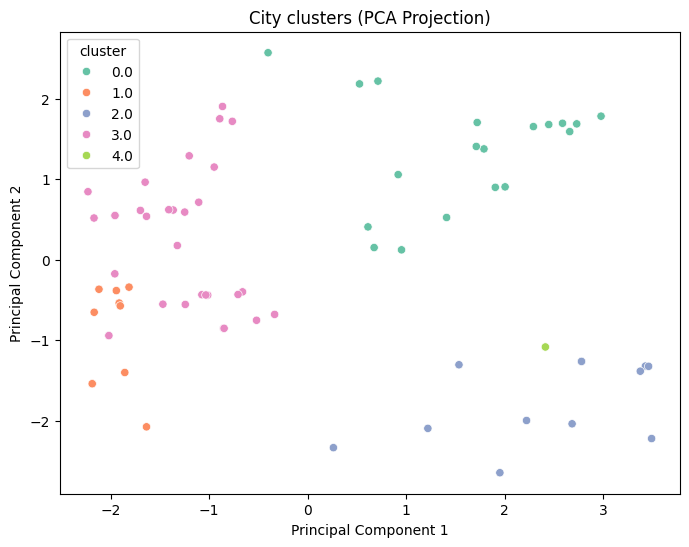

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df.loc[X.index, "pca1"] = X_pca[:, 0]
df.loc[X.index, "pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set2"
)
plt.title("City clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [17]:
import folium
df = df[
    (df["lat"].between(6, 38)) &
    (df["lon"].between(68, 98))
]

In [18]:
cluster_colors = {
    0: "blue",
    1: "red",
    2: "green",
    3: "purple",
    4: "orange"
}

In [23]:
# m = folium.Map(
#     location=[22.5, 78.9],
#     zoom_start=5,
#     tiles="CartoDB positron"
# )

from IPython.display import IFrame

m = folium.Map(location=[45.5236, -122.6750])

m.save("map.html")

IFrame("map.html", width=700, height=500)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=cluster_colors[row["cluster"]],
        fill=True,
        fill_color=cluster_colors[row["cluster"]],
        fill_opacity=0.8,
        popup=f"{row['city']} (Cluster {row['cluster']})"
    ).add_to(m)

In [24]:
m